In [ ]:
import pandas as pd
from textblob import TextBlob

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_reviews_full.csv")

print(df.head())

        review_id  product_id  \
0  R2SSSH04J4J264  B0D4SX9RC6   
1  R39X7USU3OX34C  B0D4SX9RC6   
2  R1BHCCLK5GZ5VZ  B0D4SX9RC6   
3   R4BQHA0TLLJNN  B0D4SX9RC6   
4  R3SO3HMV0YC0WB  B0D4SX9RC6   

                                        product_name  brand  rating  \
0  Beats Pill - Portable Bluetooth Speaker (2024 ...  Beats     5.0   
1  Beats Pill - Portable Bluetooth Speaker (2024 ...  Beats     5.0   
2  Beats Pill - Portable Bluetooth Speaker (2024 ...  Beats     5.0   
3  Beats Pill - Portable Bluetooth Speaker (2024 ...  Beats     5.0   
4  Beats Pill - Portable Bluetooth Speaker (2024 ...  Beats     5.0   

                                               title  \
0  5.0 out of 5 stars Really nice portable speake...   
1                     5.0 out of 5 stars Really good   
2                      5.0 out of 5 stars Beats Pill   
3  5.0 out of 5 stars The best Speaker I have eve...   
4                      5.0 out of 5 stars Beats pill   

                                     

In [ ]:
# Create new columns for polarity and subjectivity
df["Polarity"] = df["content"].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)
df["Subjectivity"] = df["content"].astype(str).apply(lambda x: TextBlob(x).sentiment.subjectivity)

# Preview the columns we need
print(df[["content", "Polarity", "Subjectivity"]].head())

                                             content  Polarity  Subjectivity
0  Needed a new portable speaker for the home set...  0.341186      0.592496
1  So I’m super picky about sound and have spent ...  0.290789      0.545175
2  I love the size, weight and quality of my Pill...  0.357143      0.664286
3  I really like the new Beats Pill 2024 speaker....  0.307318      0.663061
4  Great product, also very sturdy it survived a ...  0.223214      0.657143


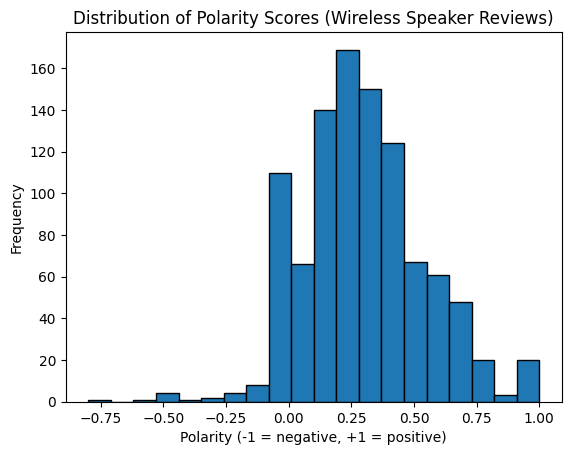

In [ ]:
plt.hist(df["Polarity"], bins=20, edgecolor="black")
plt.title("Distribution of Polarity Scores (Wireless Speaker Reviews)")
plt.xlabel("Polarity (-1 = negative, +1 = positive)")
plt.ylabel("Frequency")
plt.show()

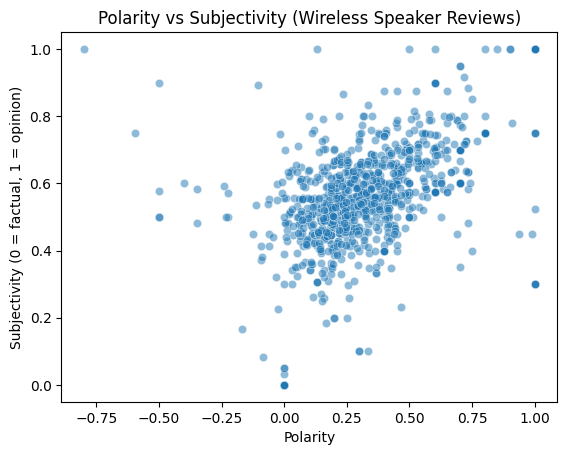

In [ ]:
sns.scatterplot(x="Polarity", y="Subjectivity", data=df, alpha=0.5)
plt.title("Polarity vs Subjectivity (Wireless Speaker Reviews)")
plt.xlabel("Polarity")
plt.ylabel("Subjectivity (0 = factual, 1 = opinion)")
plt.show()

In [ ]:
def categorize_sentiment(polarity):
    if polarity > 0.2:
        return "Positive"
    elif polarity < -0.2:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Polarity"].apply(categorize_sentiment)

print(df["Sentiment"].value_counts())

Sentiment
Positive    642
Neutral     344
Negative     13
Name: count, dtype: int64


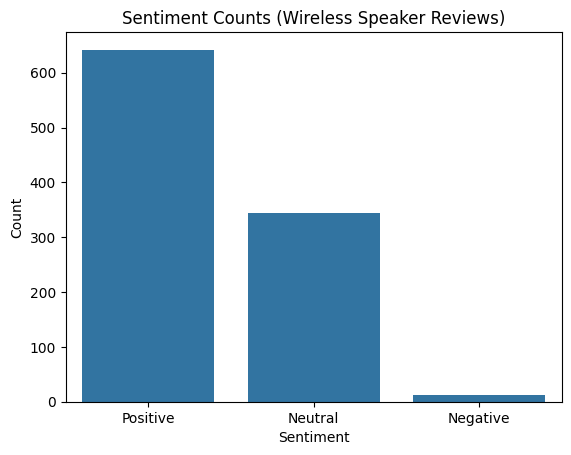

In [ ]:
sns.countplot(x="Sentiment", data=df, order=["Positive", "Neutral", "Negative"])
plt.title("Sentiment Counts (Wireless Speaker Reviews)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

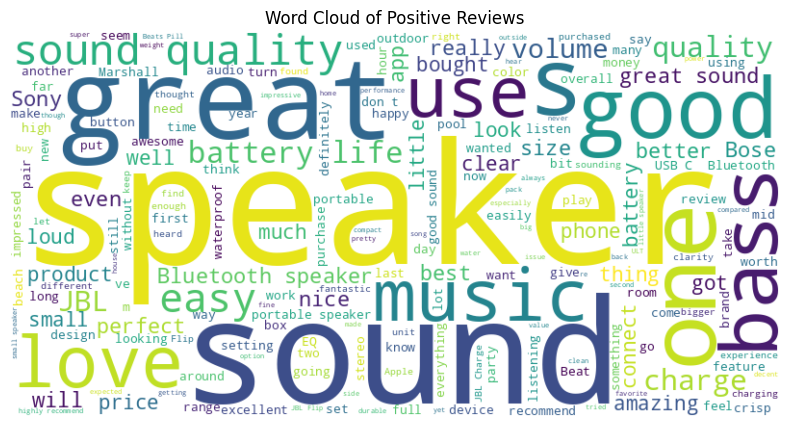

In [ ]:
from wordcloud import WordCloud

# Word Cloud for positive reviews
positive_text = " ".join(df[df["Sentiment"] == "Positive"]["content"].astype(str))
wordcloud_pos = WordCloud(background_color="white", width=800, height=400).generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Positive Reviews")
plt.show()

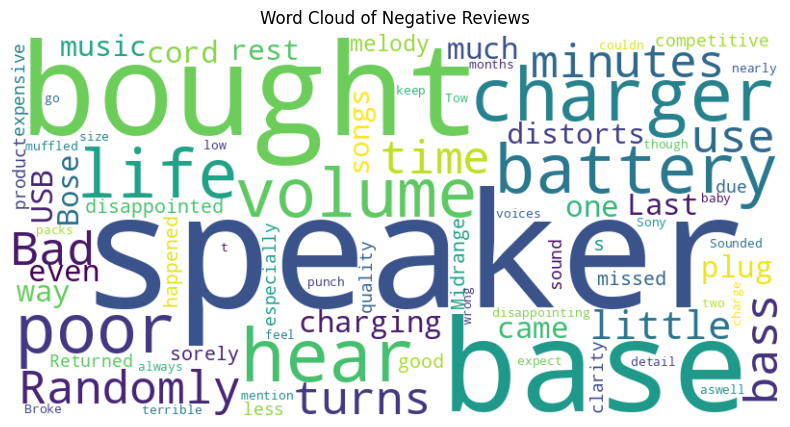

In [ ]:
# Word Cloud for negative reviews
negative_text = " ".join(df[df["Sentiment"] == "Negative"]["content"].astype(str))
wordcloud_neg = WordCloud(background_color="white", width=800, height=400).generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Negative Reviews")
plt.show()

Sentiment       Negative  Neutral  Positive
brand                                      
Bang & Olufsen         1       36        52
Beats                  2       35        75
Bose                   3       66       108
JBL                    0       71       196
Marshall               0       34        55
Sony                   7      102       156


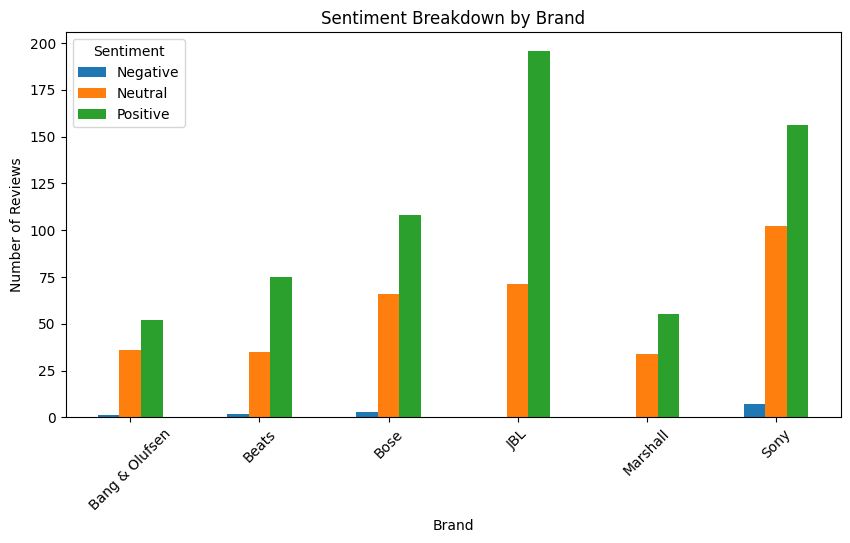

In [ ]:
# Comparing the sentiments by brand
brand_sentiment = df.groupby(["brand", "Sentiment"]).size().unstack(fill_value=0)
print(brand_sentiment)

brand_sentiment.plot(kind="bar", figsize=(10,5))
plt.title("Sentiment Breakdown by Brand")
plt.xlabel("Brand")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

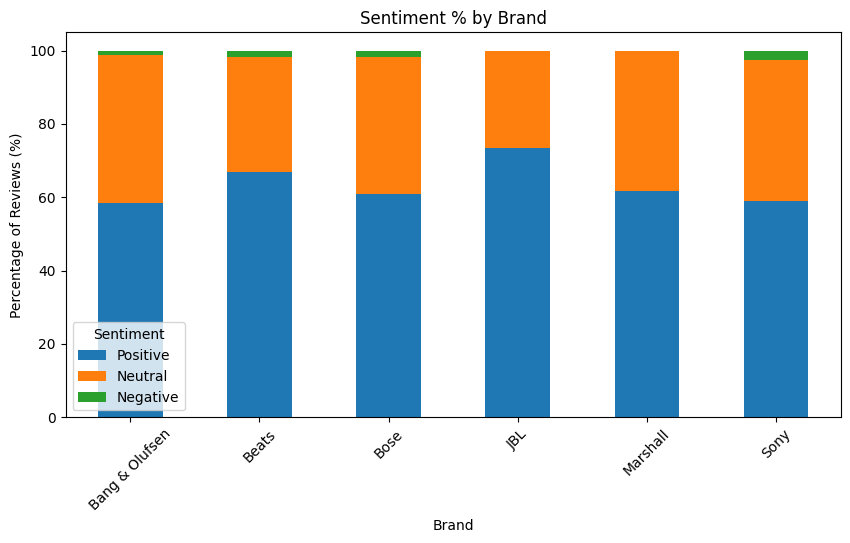

In [ ]:
# Count sentiments per brand
counts = df.groupby(["brand", "Sentiment"]).size().unstack(fill_value=0)

# Convert counts to percentages by brand
perc = counts.div(counts.sum(axis=1), axis=0) * 100

# Plot as 100% stacked bar chart
perc[["Positive", "Neutral", "Negative"]].plot(kind="bar", stacked=True, figsize=(10,5))
plt.title("Sentiment % by Brand")
plt.xlabel("Brand")
plt.ylabel("Percentage of Reviews (%)")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.show()

In [ ]:
df.to_csv("reviews_with_sentiment.csv", index=False)
print("Saved: reviews_with_sentiment.csv")

Saved: reviews_with_sentiment.csv
